#**Cardiomegaly Pulmonary Diseases**
__________________________________________________________
__________________________________________________________
__________________________________________________________


In [ ]:
import os, random, time, json
import numpy as np
import torch, torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns
from PIL import Image
from glob import glob

In [ ]:
import kagglehub


path = kagglehub.dataset_download("nih-chest-xrays/data")

print("Path to dataset files:", path)

100%|██████████| 42.0G/42.0G [44:49<00:00, 16.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/nih-chest-xrays/data/versions/3


In [ ]:
path = kagglehub.dataset_download("nih-chest-xrays/data")

In [ ]:
import pandas as pd
import os

data_path = path

csv_path = os.path.join(data_path, "Data_Entry_2017.csv")
df = pd.read_csv(csv_path)

df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


In [ ]:
df["Cardiomegaly"] = df["Finding Labels"].apply(
    lambda x: 1 if "Cardiomegaly" in x else 0
)

In [ ]:
df["Cardiomegaly"].value_counts()

,count
Cardiomegaly,
0,109344
1,2776


In [ ]:
import glob

image_paths = glob.glob(os.path.join(data_path, "images*", "*.png"))

len(image_paths)

0

In [ ]:
image_dict = {
    os.path.basename(x): x for x in image_paths
}

df["path"] = df["Image Index"].map(image_dict)
df = df.dropna(subset=["path"])

In [ ]:
positive = df[df["Cardiomegaly"] == 1]
negative = df[df["Cardiomegaly"] == 0].sample(n=len(positive)*3, random_state=42)

df_final = pd.concat([positive, negative])

In [ ]:
image_paths = glob.glob(os.path.join(data_path, "images*", "*.png"))

In [ ]:
import glob
import os

image_paths = glob.glob(os.path.join(data_path, "**", "*.png"), recursive=True)

len(image_paths)

112120

In [ ]:
image_dict = {os.path.basename(x): x for x in image_paths}

df["path"] = df["Image Index"].map(image_dict)

print(df["path"].notna().sum())
df = df.dropna(subset=["path"])

0


In [ ]:
positive = df[df["Cardiomegaly"] == 1]
negative = df[df["Cardiomegaly"] == 0].sample(
    n=len(positive) * 3,
    random_state=42
)

df_final = pd.concat([positive, negative]).sample(frac=1, random_state=42)

df_final["Cardiomegaly"].value_counts()

,count
Cardiomegaly,


In [ ]:
df["Cardiomegaly"].value_counts()

,count
Cardiomegaly,


In [ ]:
print(df["Image Index"].head(10).tolist())
print(os.path.basename(image_paths[0]))
print(image_paths[0])

[]
00019576_043.png
/root/.cache/kagglehub/datasets/nih-chest-xrays/data/versions/3/images_009/images/00019576_043.png


In [ ]:
import os

image_dict = {}

for p in image_paths:
    filename = os.path.basename(p)
    image_dict[filename] = p

sample_name = df["Image Index"].iloc[0]
print("Sample CSV image:", sample_name)
print("Found in image_dict?", sample_name in image_dict)

df["path"] = df["Image Index"].map(image_dict)

print("Matched images:", df["path"].notna().sum())

IndexError: single positional indexer is out-of-bounds

In [ ]:
image_paths[:5]

['/root/.cache/kagglehub/datasets/nih-chest-xrays/data/versions/3/images_009/images/00019576_043.png',
 '/root/.cache/kagglehub/datasets/nih-chest-xrays/data/versions/3/images_009/images/00018437_003.png',
 '/root/.cache/kagglehub/datasets/nih-chest-xrays/data/versions/3/images_009/images/00019150_004.png',
 '/root/.cache/kagglehub/datasets/nih-chest-xrays/data/versions/3/images_009/images/00019155_000.png',
 '/root/.cache/kagglehub/datasets/nih-chest-xrays/data/versions/3/images_009/images/00020341_005.png']

In [ ]:
!find /root/.cache/kagglehub/datasets/nih-chest-xrays/data/versions/3 -name "*.png" | head

/root/.cache/kagglehub/datasets/nih-chest-xrays/data/versions/3/images_009/images/00019576_043.png
/root/.cache/kagglehub/datasets/nih-chest-xrays/data/versions/3/images_009/images/00018437_003.png
/root/.cache/kagglehub/datasets/nih-chest-xrays/data/versions/3/images_009/images/00019150_004.png
/root/.cache/kagglehub/datasets/nih-chest-xrays/data/versions/3/images_009/images/00019155_000.png
/root/.cache/kagglehub/datasets/nih-chest-xrays/data/versions/3/images_009/images/00020341_005.png
/root/.cache/kagglehub/datasets/nih-chest-xrays/data/versions/3/images_009/images/00020945_010.png
/root/.cache/kagglehub/datasets/nih-chest-xrays/data/versions/3/images_009/images/00019643_031.png
/root/.cache/kagglehub/datasets/nih-chest-xrays/data/versions/3/images_009/images/00019994_001.png
/root/.cache/kagglehub/datasets/nih-chest-xrays/data/versions/3/images_009/images/00018610_040.png
/root/.cache/kagglehub/datasets/nih-chest-xrays/data/versions/3/images_009/images/00019643_033.png


In [ ]:
df = df.dropna(subset=["path"])

In [ ]:
df["Image Index"].head()

,Image Index


In [ ]:
import pandas as pd
import os
import glob

data_path = path

csv_path = os.path.join(data_path, "Data_Entry_2017.csv")
df = pd.read_csv(csv_path)

df["Cardiomegaly"] = df["Finding Labels"].apply(
    lambda x: 1 if "Cardiomegaly" in x else 0
)

image_paths = glob.glob(os.path.join(data_path, "**", "*.png"), recursive=True)


image_dict = {os.path.basename(p): p for p in image_paths}


df["path"] = df["Image Index"].map(image_dict)

print("Total rows:", len(df))
print("Total images found:", len(image_paths))
print("Matched images:", df["path"].notna().sum())
print(df["Cardiomegaly"].value_counts())

Total rows: 112120
Total images found: 112120
Matched images: 112120
Cardiomegaly
0    109344
1      2776
Name: count, dtype: int64


In [ ]:
df = df.dropna(subset=["path"])

positive = df[df["Cardiomegaly"] == 1]
negative = df[df["Cardiomegaly"] == 0].sample(
    n=len(positive) * 3,
    random_state=42
)

df_final = pd.concat([positive, negative]).sample(frac=1, random_state=42)

df_final["Cardiomegaly"].value_counts()

,count
Cardiomegaly,
0,8328
1,2776


### **CNN**

In [ ]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df_final,
    test_size=0.30,
    stratify=df_final["Cardiomegaly"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["Cardiomegaly"],
    random_state=42
)

print("Train:", train_df["Cardiomegaly"].value_counts())
print("Validation:", val_df["Cardiomegaly"].value_counts())
print("Test:", test_df["Cardiomegaly"].value_counts())

Train: Cardiomegaly
0    5829
1    1943
Name: count, dtype: int64
Validation: Cardiomegaly
0    1249
1     417
Name: count, dtype: int64
Test: Cardiomegaly
0    1250
1     416
Name: count, dtype: int64


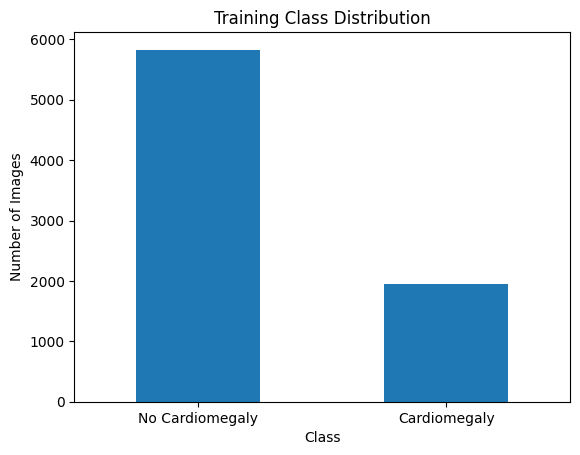

In [ ]:
import matplotlib.pyplot as plt

train_df["Cardiomegaly"].value_counts().sort_index().plot(kind="bar")
plt.title("Training Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks([0, 1], ["No Cardiomegaly", "Cardiomegaly"], rotation=0)
plt.show()

In [ ]:
plt.figure()
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("CNN Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("CNN Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

NameError: name 'history' is not defined

<Figure size 640x480 with 0 Axes>

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = test_generator.classes
y_prob = cnn_model.predict(test_generator).ravel()
y_pred = (y_prob >= 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Cardiomegaly", "Cardiomegaly"]
)

disp.plot()
plt.title("CNN Confusion Matrix")
plt.show()

NameError: name 'test_generator' is not defined

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("CNN ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

NameError: name 'y_true' is not defined

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=["No Cardiomegaly", "Cardiomegaly"]
))

NameError: name 'y_true' is not defined

In [ ]:
import numpy as np

test_generator.reset()
images, labels = next(test_generator)
preds = cnn_model.predict(images).ravel()

plt.figure(figsize=(12, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    true_label = "Cardiomegaly" if labels[i] == 1 else "No Cardiomegaly"
    pred_label = "Cardiomegaly" if preds[i] >= 0.5 else "No Cardiomegaly"
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

NameError: name 'test_generator' is not defined

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

datagen = ImageDataGenerator(rescale=1./255)

train_generator = datagen.flow_from_dataframe(
    train_df,
    x_col="path",
    y_col="Cardiomegaly",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

val_generator = datagen.flow_from_dataframe(
    val_df,
    x_col="path",
    y_col="Cardiomegaly",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

test_generator = datagen.flow_from_dataframe(
    test_df,
    x_col="path",
    y_col="Cardiomegaly",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

TypeError: If class_mode="binary", y_col="Cardiomegaly" column values must be strings.

In [ ]:
from tensorflow.keras import layers, models

cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

NameError: name 'cnn_model' is not defined

In [ ]:
train_df["Cardiomegaly"] = train_df["Cardiomegaly"].astype(str)
val_df["Cardiomegaly"] = val_df["Cardiomegaly"].astype(str)
test_df["Cardiomegaly"] = test_df["Cardiomegaly"].astype(str)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

datagen = ImageDataGenerator(rescale=1./255)

train_generator = datagen.flow_from_dataframe(
    train_df,
    x_col="path",
    y_col="Cardiomegaly",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

val_generator = datagen.flow_from_dataframe(
    val_df,
    x_col="path",
    y_col="Cardiomegaly",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

test_generator = datagen.flow_from_dataframe(
    test_df,
    x_col="path",
    y_col="Cardiomegaly",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 7772 validated image filenames belonging to 2 classes.
Found 1666 validated image filenames belonging to 2 classes.
Found 1666 validated image filenames belonging to 2 classes.


In [ ]:
from tensorflow.keras import layers, models

cnn_model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    layers.Conv2D(32, (3,3), activation="relu"),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation="relu"),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 146s 572ms/step - accuracy: 0.7451 - loss: 0.5864 - val_accuracy: 0.7491 - val_loss: 0.5321
Epoch 2/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 135s 556ms/step - accuracy: 0.7499 - loss: 0.5344 - val_accuracy: 0.7497 - val_loss: 0.5237
Epoch 3/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 135s 554ms/step - accuracy: 0.7491 - loss: 0.5165 - val_accuracy: 0.7479 - val_loss: 0.5051
Epoch 4/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 135s 554ms/step - accuracy: 0.7500 - loss: 0.5019 - val_accuracy: 0.7473 - val_loss: 0.4963
Epoch 5/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 134s 552ms/step - accuracy: 0.7492 - loss: 0.4886 - val_accuracy: 0.7503 - val_loss: 0.5070
Epoch 6/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 135s 554ms/step - accuracy: 0.7510 - loss: 0.4753 - val_accuracy: 0.7533 - val_loss: 0.4960
Epoch 7/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 135s 554ms/step - accuracy: 0.7541 - loss: 0.4618 - val_accuracy: 0.7581 - val_loss: 0.5056
Epoch 8/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 134s 553ms/step - accuracy: 0.7712 -

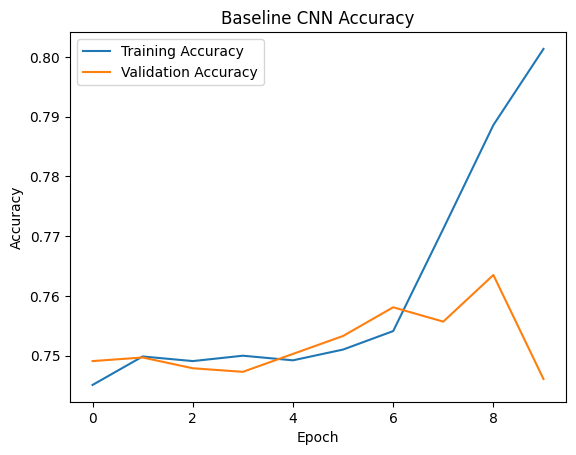

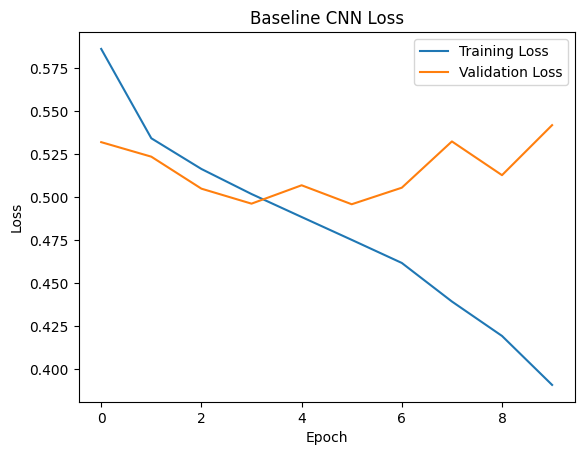

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Baseline CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Baseline CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
import numpy as np

test_generator.reset()

y_true = test_generator.classes
y_prob = cnn_model.predict(test_generator).ravel()
y_pred = (y_prob >= 0.5).astype(int)

53/53 ━━━━━━━━━━━━━━━━━━━━ 24s 450ms/step


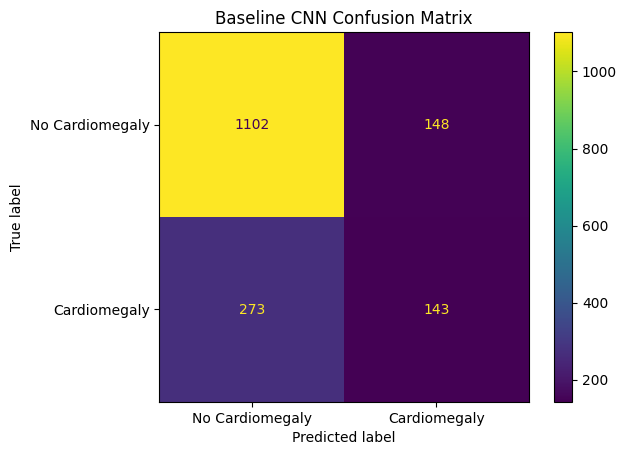

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Cardiomegaly", "Cardiomegaly"]
)

disp.plot()
plt.title("Baseline CNN Confusion Matrix")
plt.show()

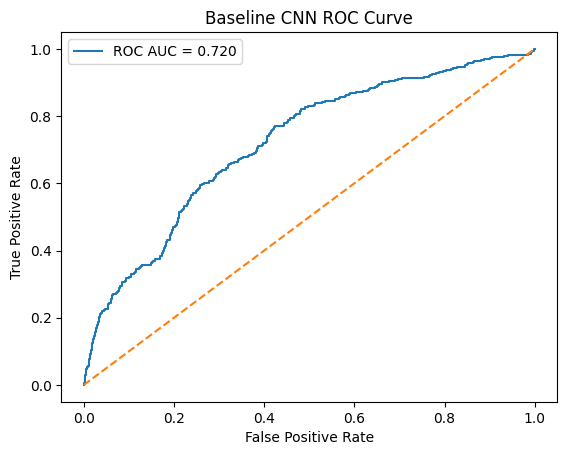

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Baseline CNN ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [ ]:
last_conv_layer_name = "conv2d_2"

In [ ]:
for layer in cnn_model.layers:
    print(layer.name)

conv2d
max_pooling2d
conv2d_1
max_pooling2d_1
conv2d_2
max_pooling2d_2
flatten
dense
dropout
dense_1


In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap)

    return heatmap.numpy()

In [ ]:
from PIL import Image

img_path = test_df["path"].iloc[0]

img = Image.open(img_path).resize((224, 224))
img_array = np.array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

In [ ]:
heatmap = make_gradcam_heatmap(
    img_array,
    cnn_model,
    last_conv_layer_name
)

AttributeError: The layer sequential has never been called and thus has no defined output.

In [ ]:
import cv2

img = cv2.imread(img_path)
img = cv2.resize(img, (224, 224))

heatmap = cv2.resize(heatmap, (224, 224))
heatmap = np.uint8(255 * heatmap)

heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed_img = heatmap * 0.4 + img

plt.imshow(superimposed_img.astype("uint8"))
plt.axis("off")
plt.title("Grad-CAM Heatmap")
plt.show()

NameError: name 'heatmap' is not defined

In [ ]:
import numpy as np

# force model to build
dummy_input = np.random.rand(1, 224, 224, 3)
cnn_model.predict(dummy_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 573ms/step


array([[0.2152008]], dtype=float32)

In [ ]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap)

    return heatmap.numpy()

In [ ]:
for layer in cnn_model.layers:
    print(layer.name)

conv2d
max_pooling2d
conv2d_1
max_pooling2d_1
conv2d_2
max_pooling2d_2
flatten
dense
dropout
dense_1


In [ ]:
last_conv_layer_name = "conv2d_2"

In [ ]:

dummy_input = np.random.rand(1, 224, 224, 3)
cnn_model.predict(dummy_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


array([[0.23897387]], dtype=float32)

In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / tf.reduce_max(heatmap)

    return heatmap.numpy()

In [ ]:
img_path = test_df["path"].iloc[0]

img = Image.open(img_path).convert("RGB").resize((224, 224))
img_array = np.array(img).astype("float32") / 255.0
img_array = np.expand_dims(img_array, axis=0)

heatmap = make_gradcam_heatmap(
    img_array,
    cnn_model,
    last_conv_layer_name="conv2d_2"
)

AttributeError: The layer sequential has never been called and thus has no defined input.

In [ ]:
original_img = cv2.imread(img_path)
original_img = cv2.resize(original_img, (224, 224))

heatmap_resized = cv2.resize(heatmap, (224, 224))
heatmap_resized = np.uint8(255 * heatmap_resized)
heatmap_color = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)

superimposed_img = heatmap_color * 0.4 + original_img

plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(superimposed_img.astype("uint8"), cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Baseline CNN Grad-CAM")
plt.show()

NameError: name 'heatmap' is not defined

In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image


cnn_model.build((None, 224, 224, 3))
cnn_model(np.zeros((1, 224, 224, 3), dtype=np.float32))

last_conv_layer_name = "conv2d_2"

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        inputs=model.layers[0].input,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.layers[-1].output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0)

    max_val = tf.reduce_max(heatmap)
    if max_val != 0:
        heatmap = heatmap / max_val

    return heatmap.numpy()

In [ ]:
img_path = test_df["path"].iloc[0]

img = Image.open(img_path).convert("RGB").resize((224, 224))
img_array = np.array(img).astype("float32") / 255.0
img_array = np.expand_dims(img_array, axis=0)

heatmap = make_gradcam_heatmap(
    img_array,
    cnn_model,
    last_conv_layer_name
)

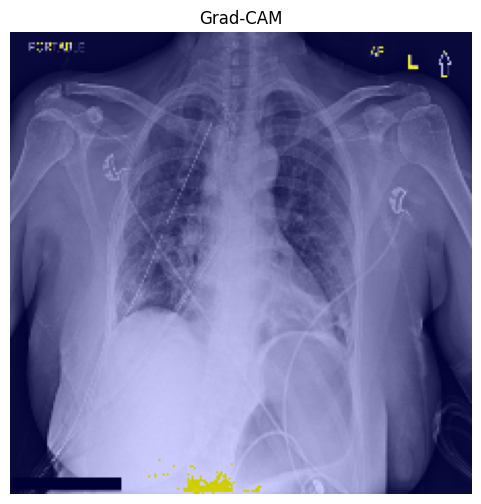

In [ ]:
original_img = cv2.imread(img_path)
original_img = cv2.resize(original_img, (224, 224))

heatmap_resized = cv2.resize(heatmap, (224, 224))
heatmap_resized = np.uint8(255 * heatmap_resized)
heatmap_color = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)

superimposed_img = heatmap_color * 0.4 + original_img

plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(superimposed_img.astype("uint8"), cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Grad-CAM")
plt.show()

### **ResNet50**

In [ ]:
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

resnet_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_resnet_gen = resnet_datagen.flow_from_dataframe(
    train_df,
    x_col="path",
    y_col="Cardiomegaly",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

val_resnet_gen = resnet_datagen.flow_from_dataframe(
    val_df,
    x_col="path",
    y_col="Cardiomegaly",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

test_resnet_gen = resnet_datagen.flow_from_dataframe(
    test_df,
    x_col="path",
    y_col="Cardiomegaly",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 7772 validated image filenames belonging to 2 classes.
Found 1666 validated image filenames belonging to 2 classes.
Found 1666 validated image filenames belonging to 2 classes.


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)


base_model.trainable = False

resnet_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
resnet_history = resnet_model.fit(
    train_resnet_gen,
    validation_data=val_resnet_gen,
    epochs=10
)

Epoch 1/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 168s 631ms/step - accuracy: 0.7258 - loss: 0.5921 - val_accuracy: 0.7503 - val_loss: 0.5226
Epoch 2/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 139s 571ms/step - accuracy: 0.7571 - loss: 0.5164 - val_accuracy: 0.7563 - val_loss: 0.5077
Epoch 3/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 139s 571ms/step - accuracy: 0.7598 - loss: 0.5011 - val_accuracy: 0.7689 - val_loss: 0.4956
Epoch 4/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 138s 568ms/step - accuracy: 0.7681 - loss: 0.4866 - val_accuracy: 0.7755 - val_loss: 0.4892
Epoch 5/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 139s 571ms/step - accuracy: 0.7780 - loss: 0.4677 - val_accuracy: 0.7713 - val_loss: 0.4851
Epoch 6/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 139s 570ms/step - accuracy: 0.7877 - loss: 0.4600 - val_accuracy: 0.7731 - val_loss: 0.4814
Epoch 7/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 138s 570ms/step - accuracy: 0.7859 - loss: 0.4534 - val_accuracy: 0.7695 - val_loss: 0.4781
Epoch 8/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 139s 571ms/step - accuracy: 0.7932 -

In [ ]:
import numpy as np

test_resnet_gen.reset()

resnet_y_true = test_resnet_gen.classes
resnet_y_prob = resnet_model.predict(test_resnet_gen).ravel()
resnet_y_pred = (resnet_y_prob >= 0.5).astype(int)

53/53 ━━━━━━━━━━━━━━━━━━━━ 32s 528ms/step


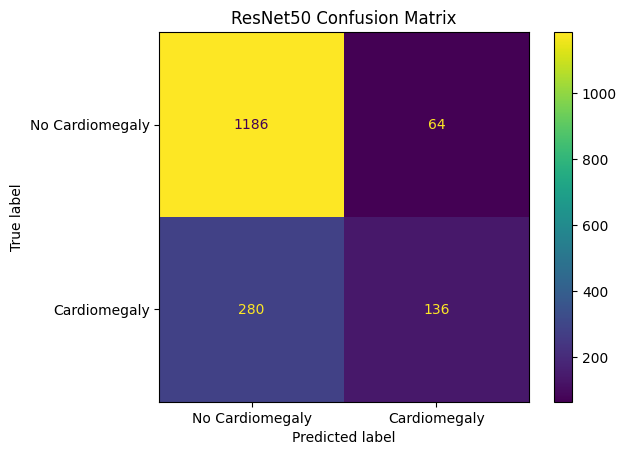

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(resnet_y_true, resnet_y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Cardiomegaly", "Cardiomegaly"]
)

disp.plot()
plt.title("ResNet50 Confusion Matrix")
plt.show()

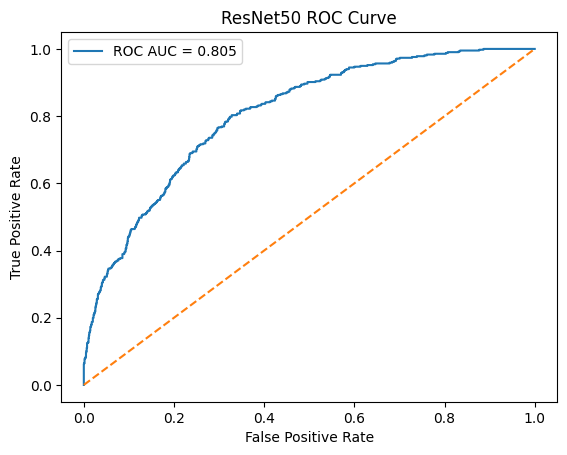

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(resnet_y_true, resnet_y_prob)
resnet_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC AUC = {resnet_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ResNet50 ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

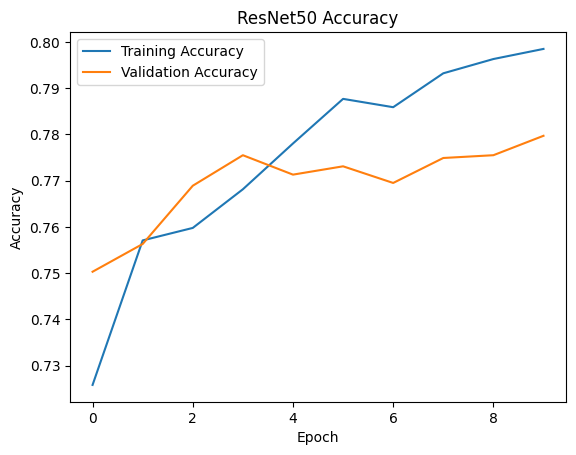

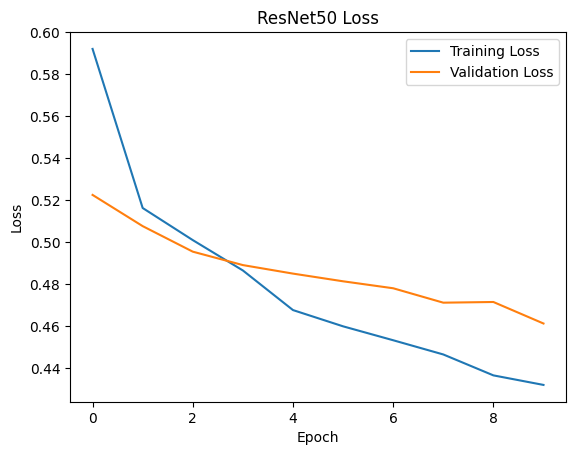

In [ ]:
plt.figure()
plt.plot(resnet_history.history["accuracy"], label="Training Accuracy")
plt.plot(resnet_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("ResNet50 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure()
plt.plot(resnet_history.history["loss"], label="Training Loss")
plt.plot(resnet_history.history["val_loss"], label="Validation Loss")
plt.title("ResNet50 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.applications.resnet50 import preprocess_input

last_conv_layer_name = "conv5_block3_out"

In [ ]:
def make_resnet_gradcam_heatmap(img_array, model, last_conv_layer_name):

    base_model = model.get_layer("resnet50")

    grad_model = tf.keras.models.Model(
        inputs=base_model.input,
        outputs=[
            base_model.get_layer(last_conv_layer_name).output,
            base_model.output
        ]
    )


    gap_layer = model.get_layer("global_average_pooling2d")
    dense_layer = model.get_layer("dense_2")
    dropout_layer = model.get_layer("dropout_1")
    output_layer = model.get_layer("dense_3")

    with tf.GradientTape() as tape:
        conv_outputs, base_outputs = grad_model(img_array)
        x = gap_layer(base_outputs)
        x = dense_layer(x)
        x = dropout_layer(x, training=False)
        predictions = output_layer(x)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0)
    max_val = tf.reduce_max(heatmap)

    if max_val != 0:
        heatmap = heatmap / max_val

    return heatmap.numpy()

In [ ]:
img_path = test_df["path"].iloc[0]

img = Image.open(img_path).convert("RGB").resize((224, 224))
img_array = np.array(img).astype("float32")
img_array = np.expand_dims(img_array, axis=0)


img_array = preprocess_input(img_array)

In [ ]:
heatmap = make_resnet_gradcam_heatmap(
    img_array,
    resnet_model,
    last_conv_layer_name
)

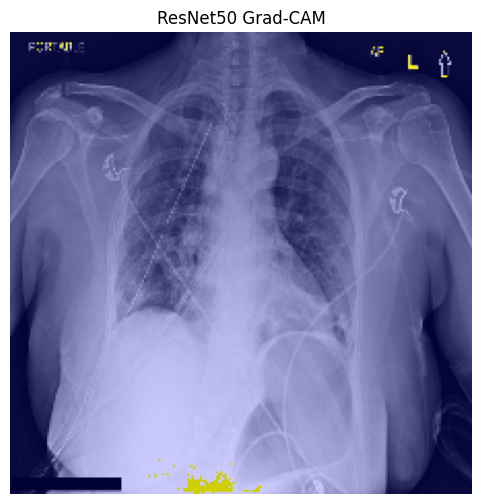

In [ ]:
original_img = cv2.imread(img_path)
original_img = cv2.resize(original_img, (224, 224))

heatmap_resized = cv2.resize(heatmap, (224, 224))
heatmap_resized = np.uint8(255 * heatmap_resized)
heatmap_color = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)

superimposed_img = heatmap_color * 0.4 + original_img

plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(superimposed_img.astype("uint8"), cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("ResNet50 Grad-CAM")
plt.show()

Found 7772 validated image filenames belonging to 2 classes.
Found 1666 validated image filenames belonging to 2 classes.
Found 1666 validated image filenames belonging to 2 classes.


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0

eff_base = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

eff_base.trainable = False

eff_model = models.Sequential([
    eff_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

eff_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

eff_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
eff_history = eff_model.fit(
    train_eff_gen,
    validation_data=val_eff_gen,
    epochs=10
)

Epoch 1/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 219s 752ms/step - accuracy: 0.7488 - loss: 0.5492 - val_accuracy: 0.7593 - val_loss: 0.5136
Epoch 2/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 134s 554ms/step - accuracy: 0.7577 - loss: 0.5138 - val_accuracy: 0.7611 - val_loss: 0.4959
Epoch 3/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 135s 554ms/step - accuracy: 0.7665 - loss: 0.4984 - val_accuracy: 0.7683 - val_loss: 0.4846
Epoch 4/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 135s 555ms/step - accuracy: 0.7702 - loss: 0.4842 - val_accuracy: 0.7719 - val_loss: 0.4789
Epoch 5/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 135s 554ms/step - accuracy: 0.7737 - loss: 0.4762 - val_accuracy: 0.7827 - val_loss: 0.4683
Epoch 6/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 135s 554ms/step - accuracy: 0.7786 - loss: 0.4719 - val_accuracy: 0.7815 - val_loss: 0.4649
Epoch 7/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 135s 556ms/step - accuracy: 0.7828 - loss: 0.4642 - val_accuracy: 0.7809 - val_loss: 0.4634
Epoch 8/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 138s 567ms/step - accuracy: 0.7880 -

In [ ]:
import numpy as np

test_eff_gen.reset()

eff_y_true = test_eff_gen.classes
eff_y_prob = eff_model.predict(test_eff_gen).ravel()
eff_y_pred = (eff_y_prob >= 0.5).astype(int)

53/53 ━━━━━━━━━━━━━━━━━━━━ 37s 562ms/step


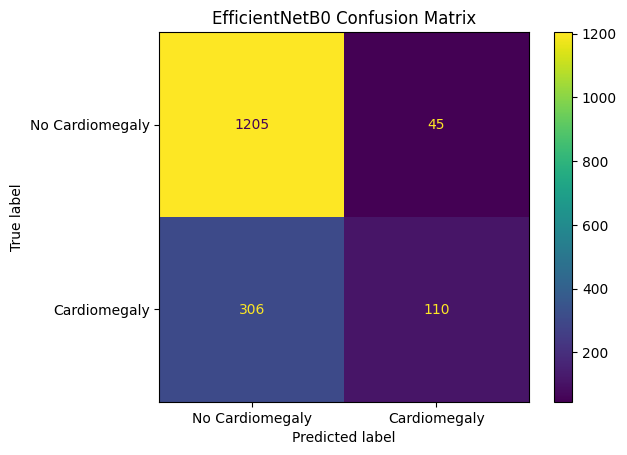

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(eff_y_true, eff_y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Cardiomegaly", "Cardiomegaly"]
)

disp.plot()
plt.title("EfficientNetB0 Confusion Matrix")
plt.show()

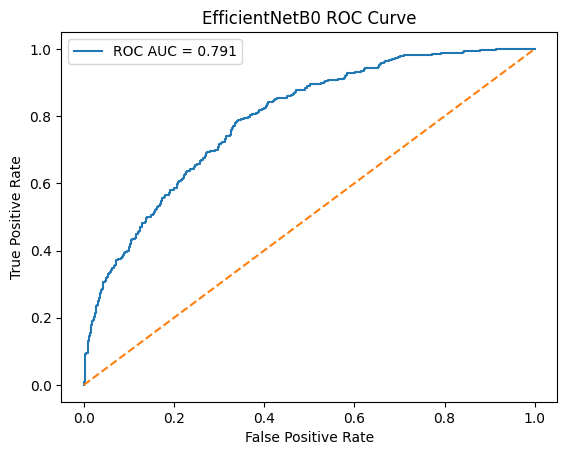

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(eff_y_true, eff_y_prob)
eff_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC AUC = {eff_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("EfficientNetB0 ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

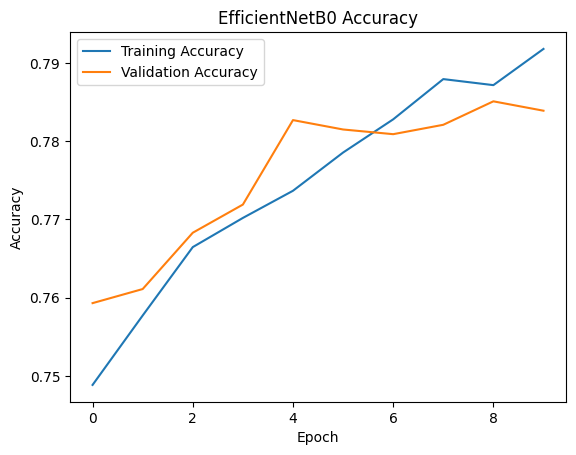

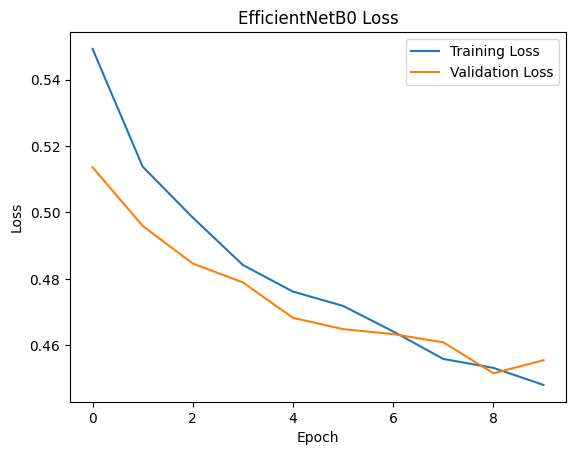

In [ ]:
plt.figure()
plt.plot(eff_history.history["accuracy"], label="Training Accuracy")
plt.plot(eff_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("EfficientNetB0 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure()
plt.plot(eff_history.history["loss"], label="Training Loss")
plt.plot(eff_history.history["val_loss"], label="Validation Loss")
plt.title("EfficientNetB0 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.applications.efficientnet import preprocess_input

# EfficientNetB0 last convolution layer
last_conv_layer_name = "top_conv"

In [ ]:
def make_eff_gradcam_heatmap(img_array, model, last_conv_layer_name):
    base_model = model.get_layer("efficientnetb0")

    grad_model = tf.keras.models.Model(
        inputs=base_model.input,
        outputs=[
            base_model.get_layer(last_conv_layer_name).output,
            base_model.output
        ]
    )

    gap_layer = model.get_layer("global_average_pooling2d_1")
    dense_layer = model.get_layer("dense_4")
    dropout_layer = model.get_layer("dropout_2")
    output_layer = model.get_layer("dense_5")

    with tf.GradientTape() as tape:
        conv_outputs, base_outputs = grad_model(img_array)
        x = gap_layer(base_outputs)
        x = dense_layer(x)
        x = dropout_layer(x, training=False)
        predictions = output_layer(x)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0)
    max_val = tf.reduce_max(heatmap)

    if max_val != 0:
        heatmap = heatmap / max_val

    return heatmap.numpy()

In [ ]:
img_path = test_df["path"].iloc[0]

img = Image.open(img_path).convert("RGB").resize((224, 224))
img_array = np.array(img).astype("float32")
img_array = np.expand_dims(img_array, axis=0)

# Important: EfficientNet preprocessing
img_array = preprocess_input(img_array)

In [ ]:
heatmap = make_eff_gradcam_heatmap(
    img_array,
    eff_model,
    last_conv_layer_name
)

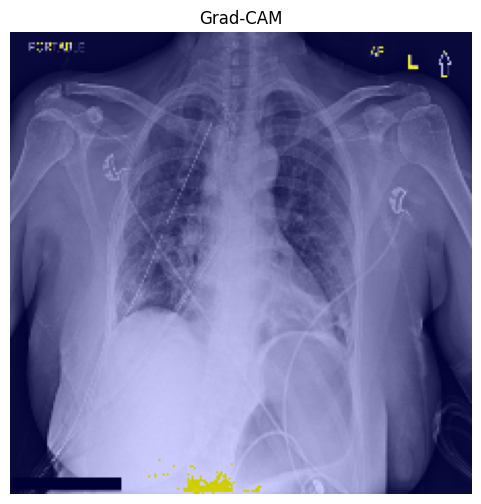

In [ ]:
original_img = cv2.imread(img_path)
original_img = cv2.resize(original_img, (224, 224))

heatmap_resized = cv2.resize(heatmap, (224, 224))
heatmap_resized = np.uint8(255 * heatmap_resized)
heatmap_color = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)

superimposed_img = heatmap_color * 0.4 + original_img

plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(superimposed_img.astype("uint8"), cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Grad-CAM")
plt.show()

In [ ]:
cnn_model.save("ResNet50.keras")

In [ ]:
from google.colab import files
files.download("ResNet50.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
plt.savefig("gradcam_example.png", bbox_inches="tight", dpi=300)

<Figure size 640x480 with 0 Axes>

In [ ]:
from google.colab import files
files.download("gradcam_example.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
plt.figure(figsize=(6,6))
plt.imshow(overlay_image)
plt.axis("off")
plt.tight_layout()
plt.savefig("gradcam_example.png", bbox_inches="tight", pad_inches=0, dpi=300)
plt.show()

NameError: name 'overlay_image' is not defined

<Figure size 600x600 with 0 Axes>

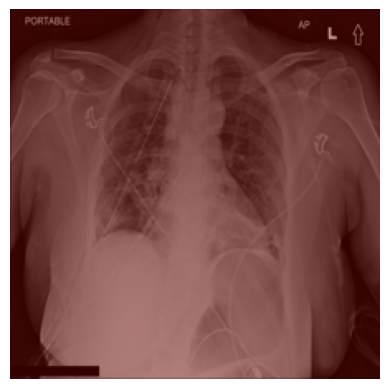

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt



heatmap = np.uint8(255 * heatmap)

heatmap = cv2.resize(heatmap, (224, 224))
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

img = np.array(img)


superimposed_img = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)


plt.imshow(superimposed_img)
plt.axis("off")
plt.show()


plt.imsave("gradcam_example.png", superimposed_img)

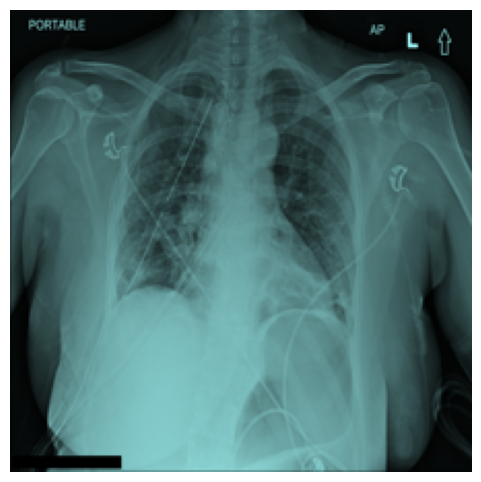

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


heatmap_resized = cv2.resize(heatmap, (224, 224))


heatmap_resized = np.maximum(heatmap_resized - 0.45, 0)
heatmap_resized = heatmap_resized / (heatmap_resized.max() + 1e-8)

heatmap_uint8 = np.uint8(255 * heatmap_resized)
heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

img = np.array(img)
if img.max() <= 1:
    img = np.uint8(img * 255)

mask = heatmap_resized > 0.15
overlay = img.copy()
overlay[mask] = cv2.addWeighted(img, 0.65, heatmap_color, 0.35, 0)[mask]

plt.figure(figsize=(6,6))
plt.imshow(overlay)
plt.axis("off")
plt.savefig("gradcam_example.png", bbox_inches="tight", pad_inches=0, dpi=300)
plt.show()

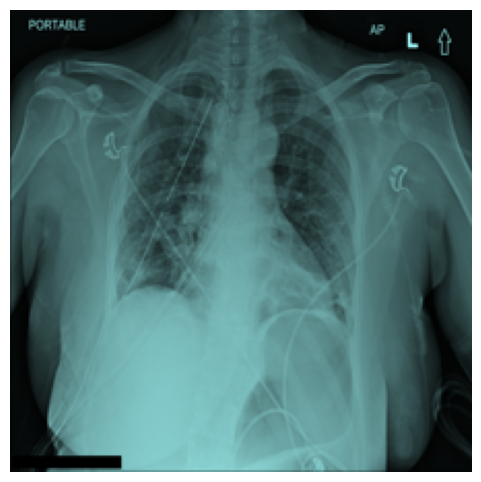

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


img = np.array(img)

if img.max() <= 1:
    img = np.uint8(img * 255)

if len(img.shape) == 2:
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

heatmap_resized = np.maximum(heatmap_resized, 0)
heatmap_resized = heatmap_resized / (heatmap_resized.max() + 1e-8)

threshold = np.percentile(heatmap_resized, 90)
mask = heatmap_resized >= threshold


heatmap_uint8 = np.uint8(255 * heatmap_resized)
heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

overlay = img.copy()


blended = cv2.addWeighted(img, 0.65, heatmap_color, 0.35, 0)
overlay[mask] = blended[mask]

plt.figure(figsize=(6, 6))
plt.imshow(overlay)
plt.axis("off")
plt.savefig("gradcam_example.png", bbox_inches="tight", pad_inches=0, dpi=300)
plt.show()

In [ ]:
last_conv_layer_name = "conv5_block3_out"

In [ ]:
def make_gradcam_heatmap(img_array, model):
    last_conv_layer = model.get_layer("conv5_block3_out")

    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[last_conv_layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = np.maximum(heatmap, 0)

    if np.max(heatmap) != 0:
        heatmap /= np.max(heatmap)

    return heatmap.numpy()

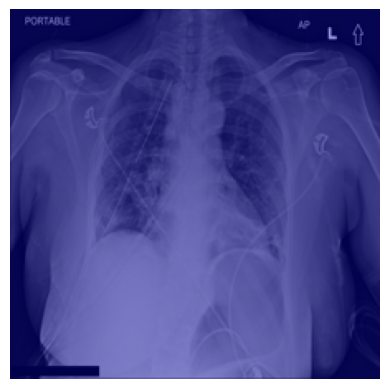

In [ ]:
heatmap = cv2.resize(heatmap, (224, 224))
heatmap = np.uint8(255 * heatmap)

heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

superimposed_img = cv2.addWeighted(img, 0.6, heatmap_color, 0.4, 0)

plt.imshow(superimposed_img)
plt.axis("off")
plt.show()